# Used Car Price Prediction — ML Pipeline
### Based on: *Advanced Feature Engineering and Machine Learning Techniques for High Accurate Price Prediction of Heterogeneous Pre-Own Cars*
> Fayyaz, Ali & Khairunnesa — Vehicles 2025, 7, 94

This notebook reproduces the full ML pipeline from the paper:
raw data → feature engineering → model training → evaluation → SHAP analysis.


## 1. Imports & Setup

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("muted")

print("All libraries loaded successfully.")


All libraries loaded successfully.


## 2. Load Dataset

In [7]:
df = pd.read_csv('used_cars.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (4009, 12)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [8]:
print("Column types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nNull-like strings:")
for col in df.columns:
    blanks = (df[col] == '').sum()
    if blanks: print(f"  {col}: {blanks} empty strings")


Column types:
brand           object
model           object
model_year       int64
milage          object
fuel_type       object
engine          object
transmission    object
ext_col         object
int_col         object
accident        object
clean_title     object
price           object
dtype: object

Missing values:
brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

Null-like strings:


## 3. Exploratory Data Analysis

ValueError: 'label' must be of length 'x'

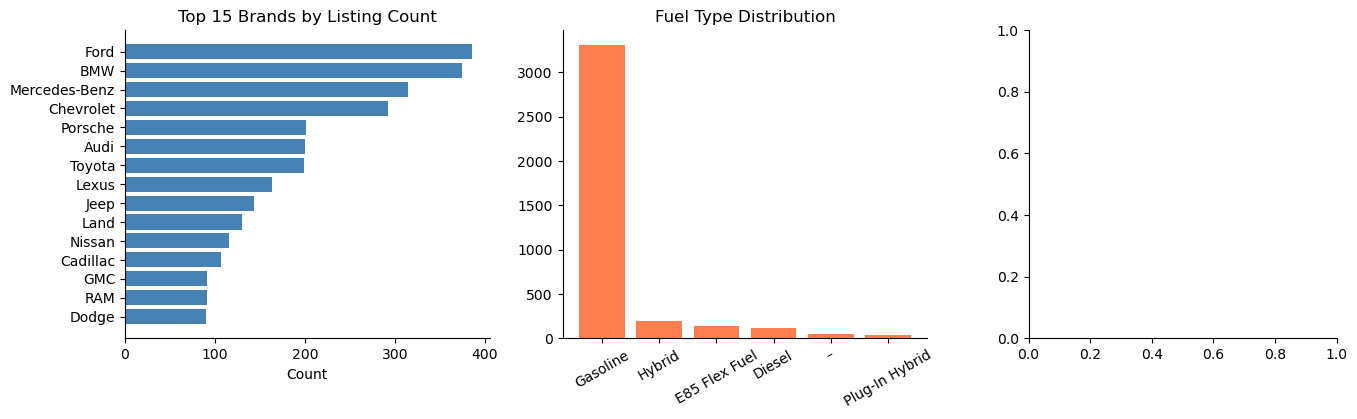

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Brand distribution (top 15)
brand_counts = df['brand'].value_counts().head(15)
axes[0].barh(brand_counts.index[::-1], brand_counts.values[::-1], color='steelblue')
axes[0].set_title('Top 15 Brands by Listing Count')
axes[0].set_xlabel('Count')

# Fuel type distribution
fuel_counts = df['fuel_type'].value_counts().head(6)
axes[1].bar(fuel_counts.index, fuel_counts.values, color='coral')
axes[1].set_title('Fuel Type Distribution')
axes[1].tick_params(axis='x', rotation=30)

# Accident history
acc_counts = df['accident'].value_counts()
axes[2].pie(acc_counts.values, labels=['None reported', 'Accident reported', 'Unknown'],
            autopct='%1.1f%%', colors=['#2ecc71','#e74c3c','#bdc3c7'])
axes[2].set_title('Accident History')

plt.tight_layout()
plt.show()


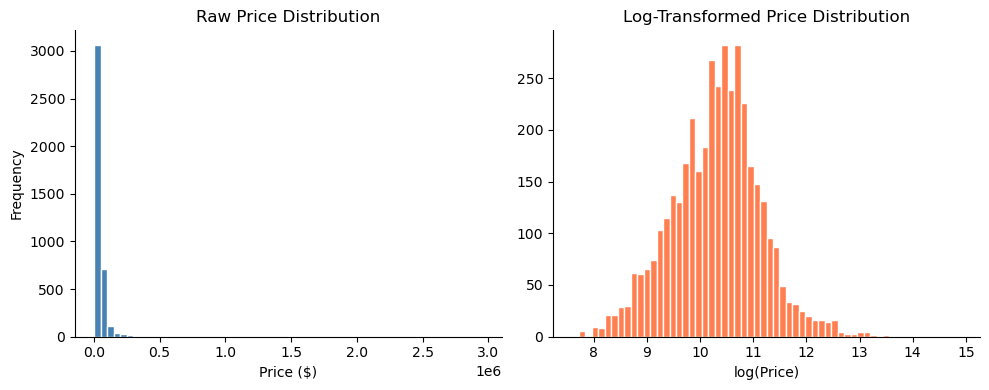

Price stats:
  Min: $2,000  |  Max: $2,954,083  |  Mean: $44,553


In [ ]:
# Raw price distribution (before cleaning)
raw_prices = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False)
raw_prices = pd.to_numeric(raw_prices, errors='coerce').dropna()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(raw_prices, bins=60, color='steelblue', edgecolor='white')
plt.title('Raw Price Distribution')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(raw_prices), bins=60, color='coral', edgecolor='white')
plt.title('Log-Transformed Price Distribution')
plt.xlabel('log(Price)')
plt.tight_layout()
plt.show()

print(f"Price stats:\n  Min: ${raw_prices.min():,.0f}  |  Max: ${raw_prices.max():,.0f}  |  Mean: ${raw_prices.mean():,.0f}")


## 4. Feature Engineering Pipeline

### 4.1 Handle Missing Values

In [10]:
df_clean = df.copy()

# Fuel type
df_clean['fuel_type'] = df_clean['fuel_type'].replace({'': 'not supported', '–': 'not supported'})
df_clean['fuel_type'] = df_clean['fuel_type'].fillna('not supported')

# Clean title
df_clean['clean_title'] = df_clean['clean_title'].fillna('No')
df_clean['clean_title'] = df_clean['clean_title'].replace({'': 'No'})

# Accident
df_clean['accident'] = df_clean['accident'].fillna('None reported')
df_clean['accident'] = df_clean['accident'].replace({'': 'None reported'})

print("Missing values after handling:")
print(df_clean[['fuel_type', 'clean_title', 'accident']].isnull().sum())


Missing values after handling:
fuel_type      0
clean_title    0
accident       0
dtype: int64


### 4.2 Standardize Numeric Fields

In [11]:
# Mileage: "51,000 mi." → 51000
df_clean['milage'] = (df_clean['milage']
    .str.replace(',', '', regex=False)
    .str.replace(' mi.', '', regex=False)
    .str.strip()
)
df_clean['milage'] = pd.to_numeric(df_clean['milage'], errors='coerce')

# Price: "$10,300" → 10300
df_clean['price'] = (df_clean['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce')

print(f"Mileage range: {df_clean['milage'].min():,.0f} – {df_clean['milage'].max():,.0f} mi")
print(f"Price range: ${df_clean['price'].min():,.0f} – ${df_clean['price'].max():,.0f}")


Mileage range: 100 – 405,000 mi
Price range: $2,000 – $2,954,083


### 4.3 Vehicle Age

In [12]:
CURRENT_YEAR = 2025
df_clean['Age'] = CURRENT_YEAR - df_clean['model_year']
df_clean.drop(columns=['model_year'], inplace=True)

print("Age distribution (years):")
print(df_clean['Age'].describe())


Age distribution (years):
count    4009.000000
mean        9.484410
std         6.104816
min         1.000000
25%         5.000000
50%         8.000000
75%        13.000000
max        51.000000
Name: Age, dtype: float64


### 4.4 Extract Horsepower & Engine Displacement (Regex)

In [13]:
def extract_horsepower(engine_str):
    if pd.isna(engine_str):
        return np.nan
    match = re.search(r'(\d+\.?\d*)\s*HP', str(engine_str), re.IGNORECASE)
    if match:
        return float(match.group(1))
    return np.nan

def extract_displacement(engine_str):
    if pd.isna(engine_str):
        return np.nan
    match = re.search(r'(\d+\.?\d*)\s*(?:L|Liter)', str(engine_str), re.IGNORECASE)
    if match:
        return float(match.group(1))
    return np.nan

df_clean['Horsepower'] = df_clean['engine'].apply(extract_horsepower)
df_clean['Engine_Displacement'] = df_clean['engine'].apply(extract_displacement)

# Impute missing with mean
df_clean['Horsepower'].fillna(df_clean['Horsepower'].mean(), inplace=True)
df_clean['Engine_Displacement'].fillna(df_clean['Engine_Displacement'].mean(), inplace=True)

df_clean.drop(columns=['engine'], inplace=True)

print(f"Horsepower extracted: {df_clean['Horsepower'].notna().sum()} | mean: {df_clean['Horsepower'].mean():.1f} HP")
print(f"Displacement extracted: {df_clean['Engine_Displacement'].notna().sum()} | mean: {df_clean['Engine_Displacement'].mean():.2f} L")


Horsepower extracted: 4009 | mean: 332.2 HP
Displacement extracted: 4009 | mean: 3.68 L


### 4.5 Standardize Transmission

In [14]:
def standardize_transmission(t):
    if pd.isna(t):
        return 'Other'
    t = str(t).lower()
    # Manual indicators
    if re.search(r'manual|mt|m/t|\d+.speed.m', t):
        return 'Manual'
    # Automatic indicators
    if re.search(r'automatic|auto|a/t|at|cvt|dct|dsg|pdk|tiptronic|dual.clutch', t):
        return 'Automatic'
    return 'Other'

df_clean['transmission_std'] = df_clean['transmission'].apply(standardize_transmission)

# Encode: Automatic=1, Manual=2, Other=3
trans_map = {'Automatic': 1, 'Manual': 2, 'Other': 3}
df_clean['transmission'] = df_clean['transmission_std'].map(trans_map)
df_clean.drop(columns=['transmission_std'], inplace=True)

print("Transmission distribution:")
print(pd.Series(trans_map).reset_index().rename(columns={'index':'type', 0:'code'}))
print("\nValue counts:", df_clean['transmission'].value_counts().to_dict())


Transmission distribution:
        type  code
0  Automatic     1
1     Manual     2
2      Other     3

Value counts: {1: 3211, 3: 422, 2: 376}


### 4.6 Normalize Colors

In [15]:
BASE_COLORS = ['black', 'white', 'silver', 'gray', 'red', 'blue',
               'brown', 'green', 'beige', 'gold', 'orange', 'yellow']

def normalize_color(c):
    if pd.isna(c):
        return 'Other'
    c_lower = str(c).lower()
    for base in BASE_COLORS:
        if base in c_lower:
            return base.capitalize()
    return 'Other'

df_clean['ext_col'] = df_clean['ext_col'].apply(normalize_color)
df_clean['int_col'] = df_clean['int_col'].apply(normalize_color)

print("Exterior colors after normalization:")
print(df_clean['ext_col'].value_counts())


Exterior colors after normalization:
ext_col
Black     1016
White      922
Gray       535
Silver     421
Blue       395
Red        311
Other      137
Green       80
Brown       44
Gold        42
Beige       39
Orange      37
Yellow      30
Name: count, dtype: int64


### 4.7 Binary Encoding

In [16]:
# Accident history
df_clean['accident'] = df_clean['accident'].apply(
    lambda x: 1 if 'accident' in str(x).lower() else 0
)

# Clean title
df_clean['clean_title'] = df_clean['clean_title'].apply(
    lambda x: 1 if str(x).strip().lower() == 'yes' else 0
)

print("Accident (1=yes):", df_clean['accident'].value_counts().to_dict())
print("Clean title (1=yes):", df_clean['clean_title'].value_counts().to_dict())


Accident (1=yes): {0: 3023, 1: 986}
Clean title (1=yes): {1: 3413, 0: 596}


### 4.8 Label Encoding (Fuel Type, Colors)

In [17]:
le = LabelEncoder()
df_clean['fuel_type'] = le.fit_transform(df_clean['fuel_type'].astype(str))
df_clean['ext_col']   = le.fit_transform(df_clean['ext_col'].astype(str))
df_clean['int_col']   = le.fit_transform(df_clean['int_col'].astype(str))

print("Encoded columns: fuel_type, ext_col, int_col")


Encoded columns: fuel_type, ext_col, int_col


### 4.9 Target Encoding for Brand

In [18]:
brand_mean_price = df_clean.groupby('brand')['price'].mean()
df_clean['brand'] = df_clean['brand'].map(brand_mean_price)

# Drop model column (too high cardinality, not used in paper)
df_clean.drop(columns=['model'], inplace=True)

print("Brand target-encoded. Sample:")
print(df_clean[['brand']].describe())


Brand target-encoded. Sample:
              brand
count  4.009000e+03
mean   4.455319e+04
std    4.677512e+04
min    5.000000e+03
25%    3.002600e+04
50%    3.672274e+04
75%    4.302916e+04
max    1.950995e+06


### 4.10 Drop Remaining NaNs & Log-Transform Price

In [19]:
df_clean.dropna(inplace=True)
print(f"Shape after dropping NaNs: {df_clean.shape}")

# Log-transform price to reduce right skew
df_clean['price'] = np.log1p(df_clean['price'])

print(f"Log price range: {df_clean['price'].min():.2f} – {df_clean['price'].max():.2f}")
df_clean.head()


Shape after dropping NaNs: (4009, 12)
Log price range: 7.60 – 14.90


,brand,milage,fuel_type,transmission,ext_col,int_col,accident,clean_title,price,Age,Horsepower,Engine_Displacement
0,36240.880829,51000,1,1,1,1,1,1,9.239996,12,300.000000,3.7
1,18946.875000,34742,2,1,8,5,1,1,10.545499,4,332.206498,3.8
2,35668.521472,22372,2,1,2,1,0,0,10.907771,3,332.206498,3.5
3,22927.644068,88900,3,1,1,1,0,1,9.648660,10,354.000000,3.5
4,39907.430000,9835,2,1,11,1,0,0,10.463103,4,332.206498,2.0


## 5. Outlier Removal (IQR Method)

Removed 427 outlier rows. Remaining: 3582


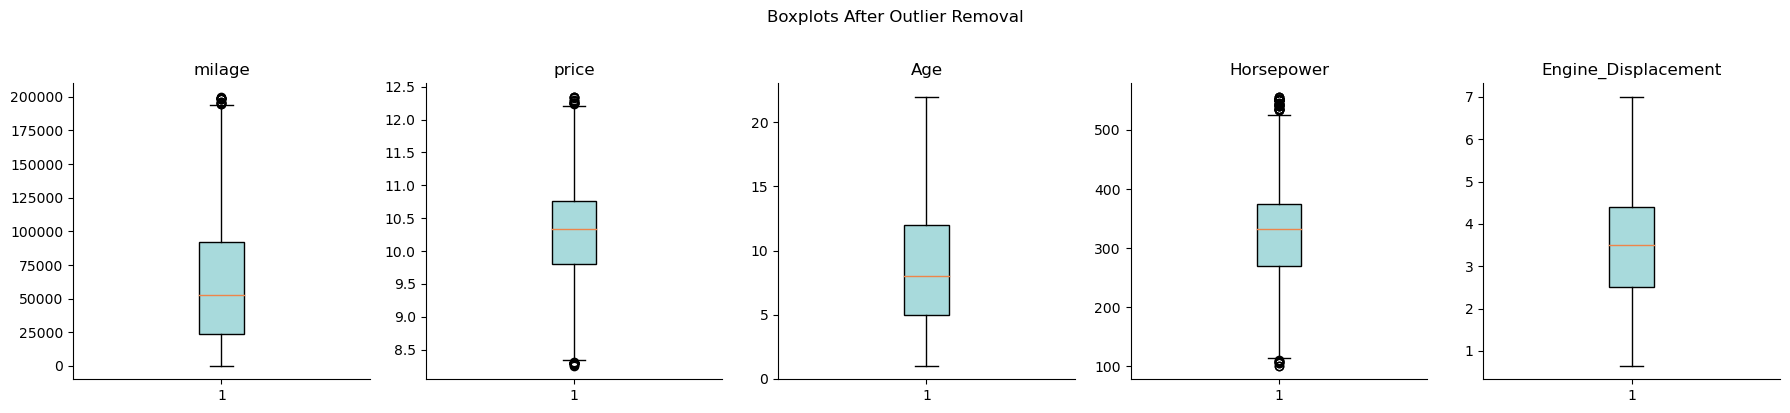

In [20]:
def remove_outliers_iqr(df, columns):
    df_out = df.copy()
    removed = 0
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before = len(df_out)
        df_out = df_out[(df_out[col] >= lower) & (df_out[col] <= upper)]
        removed += before - len(df_out)
    print(f"Removed {removed} outlier rows. Remaining: {len(df_out)}")
    return df_out

outlier_cols = ['milage', 'price', 'Age', 'Horsepower', 'Engine_Displacement']
df_clean = remove_outliers_iqr(df_clean, outlier_cols)

# Visualize after removal
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 4))
for ax, col in zip(axes, outlier_cols):
    ax.boxplot(df_clean[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#a8dadc'))
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Boxplots After Outlier Removal', y=1.02)
plt.tight_layout()
plt.show()


## 6. Correlation Analysis (After Feature Engineering)

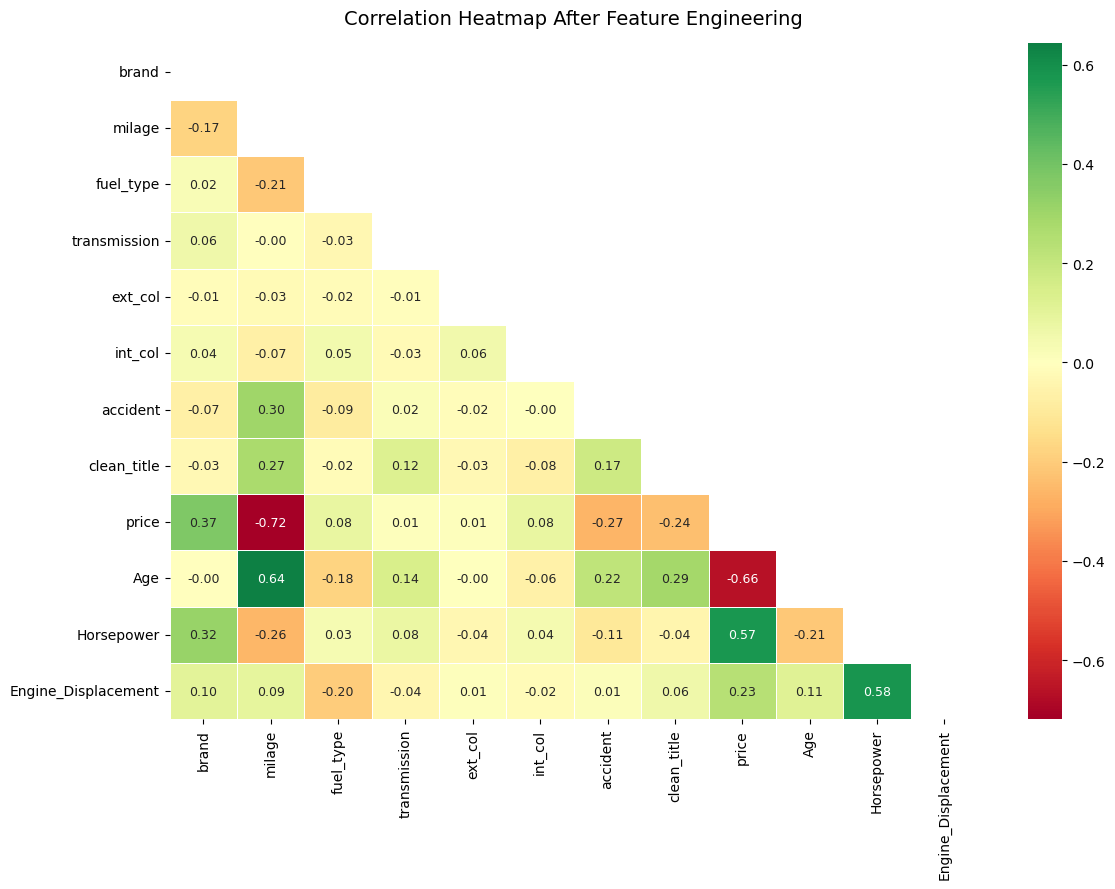

In [21]:
corr_matrix = df_clean.corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Heatmap After Feature Engineering', fontsize=14, pad=14)
plt.tight_layout()
plt.show()


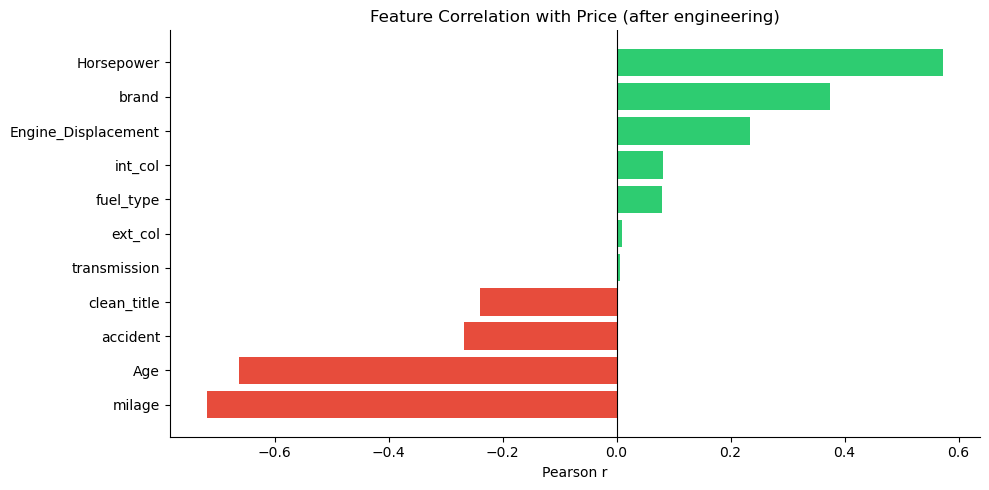

In [22]:
# Feature importance by correlation with price
corr_with_price = df_clean.corr()['price'].drop('price').sort_values()
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_with_price.values]

plt.figure(figsize=(10, 5))
plt.barh(corr_with_price.index, corr_with_price.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Price (after engineering)')
plt.xlabel('Pearson r')
plt.tight_layout()
plt.show()


## 7. Train / Test Split (80/20)

In [23]:
X = df_clean.drop(columns=['price'])
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set:  {X_train.shape}")
print(f"Test set:      {X_test.shape}")
print(f"Features used: {list(X.columns)}")


Training set:  (2865, 11)
Test set:      (717, 11)
Features used: ['brand', 'milage', 'fuel_type', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'Age', 'Horsepower', 'Engine_Displacement']


## 8. Model Training & Evaluation

In [24]:
results = {}

def evaluate(name, model, X_tr, X_te, y_tr, y_te, scaled=False):
    Xtr = X_tr if not scaled else X_train_scaled
    Xte = X_te if not scaled else X_test_scaled
    model.fit(Xtr, y_tr)
    preds = model.predict(Xte)
    r2   = r2_score(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    cv   = cross_val_score(model, Xtr, y_tr, cv=5, scoring='r2')
    results[name] = {'R2': r2, 'RMSE': rmse, 'CV_mean': cv.mean(), 'CV_std': cv.std()}
    print(f"{name:30s}  R²={r2:.4f}  RMSE={rmse:.4f}  CV={cv.mean():.4f}±{cv.std():.4f}")
    return model

print(f"{'Model':30s}  {'R²':>8}  {'RMSE':>8}  {'CV (5-fold)':>14}")
print("-" * 70)


Model                                 R²      RMSE     CV (5-fold)
----------------------------------------------------------------------


### 8.1 Linear Regression (Baseline)

In [25]:
lr = evaluate('Linear Regression', LinearRegression(),
              X_train_scaled, X_test_scaled, y_train, y_test, scaled=True)


Linear Regression               R²=0.8064  RMSE=0.3349  CV=0.7820±0.0236


### 8.2 Support Vector Regression

In [26]:
svr = evaluate('SVR', SVR(C=10, gamma=0.1, epsilon=0.1),
               X_train_scaled, X_test_scaled, y_train, y_test, scaled=True)


SVR                             R²=0.8352  RMSE=0.3090  CV=0.8123±0.0142


### 8.3 Random Forest

In [27]:
rf = evaluate('Random Forest', RandomForestRegressor(n_estimators=150, random_state=42),
              X_train, X_test, y_train, y_test)


Random Forest                   R²=0.8667  RMSE=0.2779  CV=0.8401±0.0158


### 8.4 XGBoost (Base)

In [28]:
xgb_base = evaluate('XGBoost (Base)', XGBRegressor(n_estimators=300, learning_rate=0.1,
                                                    random_state=42, verbosity=0),
                    X_train, X_test, y_train, y_test)


XGBoost (Base)                  R²=0.8904  RMSE=0.2520  CV=0.8717±0.0104


### 8.5 XGBoost with Grid Search Hyperparameters

In [29]:
# Best params from paper: colsample_bytree=0.8, lr=0.1, max_depth=5,
# min_child_weight=1, n_estimators=300, subsample=1.0
xgb_tuned = evaluate('XGBoost (Tuned)', XGBRegressor(
    colsample_bytree=0.8, learning_rate=0.1, max_depth=5,
    min_child_weight=1, n_estimators=300, subsample=1.0,
    random_state=42, verbosity=0),
    X_train, X_test, y_train, y_test)


XGBoost (Tuned)                 R²=0.8973  RMSE=0.2439  CV=0.8804±0.0106


### 8.6 LightGBM

In [30]:
lgbm = evaluate('LightGBM', LGBMRegressor(n_estimators=300, random_state=42, verbose=-1),
                X_train, X_test, y_train, y_test)


LightGBM                        R²=0.8908  RMSE=0.2515  CV=0.8726±0.0126


### 8.7 CatBoost

In [31]:
cat = evaluate('CatBoost', CatBoostRegressor(iterations=300, random_seed=42, verbose=0),
               X_train, X_test, y_train, y_test)


CatBoost                        R²=0.8967  RMSE=0.2446  CV=0.8795±0.0105


### 8.8 Stacking Regressor (Best Model)

In [32]:
estimators = [
    ('svr', SVR(C=10, gamma=0.1, epsilon=0.1)),
    ('rf',  RandomForestRegressor(n_estimators=500, max_depth=10, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=42, verbosity=0)),
]
stack = evaluate('Stacking Regressor',
                 StackingRegressor(estimators=estimators,
                                   final_estimator=LinearRegression(), cv=5),
                 X_train_scaled, X_test_scaled, y_train, y_test, scaled=True)


Stacking Regressor              R²=0.8958  RMSE=0.2457  CV=0.8749±0.0106


## 9. Results Summary Table

In [33]:
results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
results_df = results_df.round(4)
results_df.columns = ['Test R²', 'Test RMSE', 'CV Mean R²', 'CV Std R²']
print(results_df.to_string())
results_df


                    Test R²  Test RMSE  CV Mean R²  CV Std R²
XGBoost (Tuned)      0.8973     0.2439      0.8804     0.0106
CatBoost             0.8967     0.2446      0.8795     0.0105
Stacking Regressor   0.8958     0.2457      0.8749     0.0106
LightGBM             0.8908     0.2515      0.8726     0.0126
XGBoost (Base)       0.8904     0.2520      0.8717     0.0104
Random Forest        0.8667     0.2779      0.8401     0.0158
SVR                  0.8352     0.3090      0.8123     0.0142
Linear Regression    0.8064     0.3349      0.7820     0.0236


,Test R²,Test RMSE,CV Mean R²,CV Std R²
XGBoost (Tuned),0.8973,0.2439,0.8804,0.0106
CatBoost,0.8967,0.2446,0.8795,0.0105
Stacking Regressor,0.8958,0.2457,0.8749,0.0106
LightGBM,0.8908,0.2515,0.8726,0.0126
XGBoost (Base),0.8904,0.2520,0.8717,0.0104
Random Forest,0.8667,0.2779,0.8401,0.0158
SVR,0.8352,0.3090,0.8123,0.0142
Linear Regression,0.8064,0.3349,0.7820,0.0236


## 10. Model Performance Visualizations

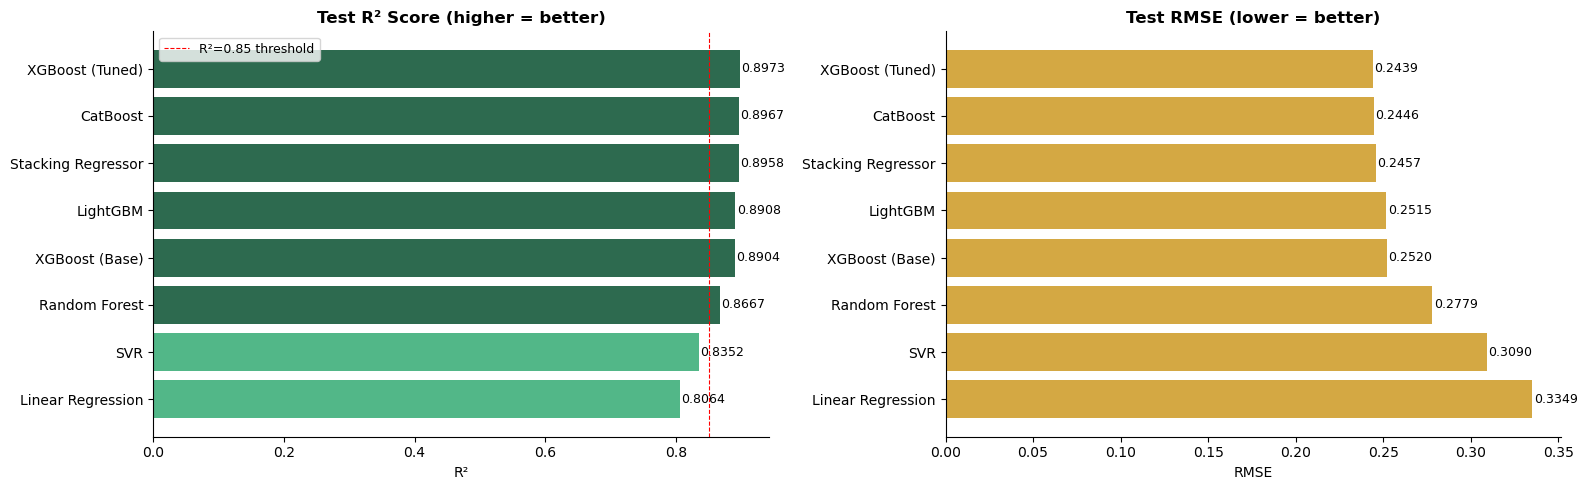

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# R² comparison
r2_vals  = results_df['Test R²'].values
rmse_vals = results_df['Test RMSE'].values
names    = results_df.index.tolist()
colors_r2 = ['#2d6a4f' if v > 0.85 else '#52b788' if v > 0.75 else '#b7e4c7' for v in r2_vals]

axes[0].barh(names[::-1], r2_vals[::-1], color=colors_r2[::-1])
axes[0].set_title('Test R² Score (higher = better)', fontweight='bold')
axes[0].set_xlabel('R²')
axes[0].axvline(0.85, color='red', linestyle='--', linewidth=0.8, label='R²=0.85 threshold')
axes[0].legend(fontsize=9)
for i, v in enumerate(r2_vals[::-1]):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

# RMSE comparison
axes[1].barh(names[::-1], rmse_vals[::-1], color='#d4a843')
axes[1].set_title('Test RMSE (lower = better)', fontweight='bold')
axes[1].set_xlabel('RMSE')
for i, v in enumerate(rmse_vals[::-1]):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


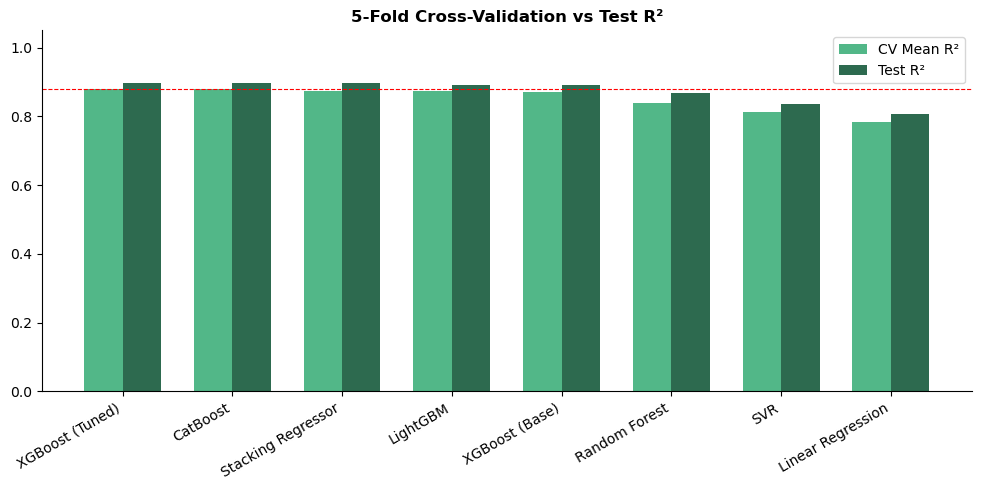

In [35]:
# CV Mean vs Test R²
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df['CV Mean R²'], width, label='CV Mean R²', color='#52b788')
ax.bar(x + width/2, results_df['Test R²'],    width, label='Test R²',    color='#2d6a4f')
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.set_title('5-Fold Cross-Validation vs Test R²', fontweight='bold')
ax.legend()
ax.axhline(0.88, color='red', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()


## 11. SHAP Feature Importance Analysis

In [ ]:
try:
    import shap
    shap.initjs()

    # SHAP for XGBoost (Tuned) — fast tree explainer
    explainer = shap.TreeExplainer(xgb_tuned)
    shap_values = explainer.shap_values(X_test)

    plt.figure(figsize=(10, 5))
    shap.summary_plot(shap_values, X_test, plot_type='bar',
                      plot_size=(10, 5), show=False)
    plt.title('SHAP Mean |Feature Importance| — XGBoost (Tuned)')
    plt.tight_layout()
    plt.show()

    # Beeswarm plot
    shap.summary_plot(shap_values, X_test, show=False)
    plt.title('SHAP Beeswarm — XGBoost (Tuned)')
    plt.tight_layout()
    plt.show()

except ImportError:
    print("SHAP not installed. Run: pip install shap")
    print("Then re-run this cell.")
    print("\nFalling back to XGBoost built-in feature importance:")
    feat_imp = pd.Series(xgb_tuned.feature_importances_, index=X.columns).sort_values(ascending=True)
    feat_imp.plot(kind='barh', figsize=(9, 5), color='#52b788')
    plt.title('XGBoost Feature Importance (gain)')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()


## 12. Predict on New Sample

In [36]:
# Example: predict price of a 2020 Toyota Camry, 35k miles, 200HP, 2.5L, Gasoline, Automatic, No Accident
sample = pd.DataFrame([{
    'brand':              brand_mean_price.get('Toyota', brand_mean_price.mean()),
    'milage':             35000,
    'fuel_type':          1,        # Gasoline (encoded)
    'transmission':       1,        # Automatic
    'ext_col':            0,        # Black (encoded)
    'int_col':            0,        # Black (encoded)
    'accident':           0,        # No accident
    'clean_title':        1,        # Clean title
    'Age':                5,        # 2025 - 2020
    'Horsepower':         200.0,
    'Engine_Displacement': 2.5,
}])

# Align columns to match training set order
sample = sample[X.columns]

# Predict with best model (Stacking uses scaled input)
sample_scaled = scaler.transform(sample)
log_pred = stack.predict(sample_scaled)[0]
price_pred = np.expm1(log_pred)

print(f"Predicted Price: ${price_pred:,.0f}")
print(f"(log-scale prediction: {log_pred:.4f})")


Predicted Price: $34,290
(log-scale prediction: 10.4426)
